# 🌾 Part 1: Crop Classification Pipeline
### Paper: *A Lightweight CNN-Transformer Network for Pixel-Based Crop Mapping Using Time-Series Sentinel-2 Imagery*

This notebook covers:
1. **Configuration** — paths, bands, hyperparameters
2. **Data Loading** — read `.SAFE` scenes, parse dates
3. **Cloud Filtering** — SCL-based masking
4. **Vegetation Indices** — NDVI, EVI, NDWI, LSWI
5. **Time-Series Construction**
6. **Exploratory Data Analysis (EDA)** — RGB composites, NDVI plots, class distribution
7. **Temporal Interpolation** — fixed 30-step grid
8. **Normalization**
9. **Dataset Preparation** — pixel-based samples
10. **CNN-Transformer Model** — architecture, training, evaluation

## 0. Install Dependencies

## 1. Imports

In [1]:
# Run this cell once to install required packages
import subprocess, sys
pkgs = [
    "numpy", "rasterio", "xarray", "matplotlib",
    "geopandas", "scipy", "scikit-learn", "seaborn",
    "torch", "torchvision", "einops", "tqdm"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages installed")

✅ All packages installed


In [2]:
import os, glob, warnings
import numpy as np
import rasterio
from rasterio.enums import Resampling
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("✅ Imports OK")

✅ Imports OK


## 2. Configuration
> ⚠️ **Edit the paths below** to point to your data before running.

In [15]:
class Config:
    # ── Paths ────────────────────────────────────────────────────────────
    SAFE_DIR   = r"C:\Users\HP\Desktop\SII\aarn\projet"                        # folder with .SAFE dirs
    CDL_PATH   = r"C:\SII\aarn\projet\cdl\cdl_california_2021.tif" # CDL GeoTIFF label
    OUTPUT_DIR = r"C:\SII\aarn\projet\outputs"

    # ── Sentinel-2 bands (10 bands as in the paper) ──────────────────────
    BANDS      = ["B02","B03","B04","B05","B06",
                  "B07","B08","B8A","B11","B12"]
    RESOLUTION = "60m"   # "10m" | "20m" | "60m"

    # ── Temporal ─────────────────────────────────────────────────────────
    YEAR         = 2021
    N_TIMESTEPS  = 30     # fixed temporal grid (paper §3.2)
    CLOUD_THRESH = 0.20   # max cloud fraction per scene

    # ── CDL crop classes (USDA codes → label) ────────────────────────────
    CDL_CLASSES = {
        1:  "Corn",
        2:  "Cotton",
        3:  "Rice",
        5:  "Soybeans",
        6:  "Sunflower",
        21: "Wheat",
        24: "Winter Wheat",
        75: "Almonds",
        204:"Pistachios",
    }

    # ── Model hyperparameters ────────────────────────────────────────────
    N_BANDS    = 10
    HIDDEN_DIM = 64
    N_HEADS    = 4
    N_LAYERS   = 2
    DROPOUT    = 0.1
    BATCH_SIZE = 512
    EPOCHS     = 50
    LR         = 1e-3
    TRAIN_RATIO= 0.70
    VAL_RATIO  = 0.15

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
print(f"✅ Output dir: {Config.OUTPUT_DIR}")

✅ Output dir: C:\SII\aarn\projet\outputs


## 3. Data Loading — Read `.SAFE` Scenes

In [16]:
def find_safe_scenes(safe_dir: str):
    """Return sorted list of .SAFE directories."""
    scenes = sorted(glob.glob(os.path.join(safe_dir, "*.SAFE")))
    print(f"[INFO] Found {len(scenes)} .SAFE scenes in {safe_dir}")
    for s in scenes:
        print(f"   • {Path(s).name}")
    return scenes


def parse_scene_date(safe_path: str):
    """Extract acquisition date from .SAFE folder name."""
    name     = Path(safe_path).name          # S2A_MSIL2A_20210628T184921_...
    date_str = name.split("_")[2][:8]       # '20210628'
    return np.datetime64(f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}")


def read_scene_bands(safe_path: str, bands: list, resolution: str = "10m"):
    """Read selected bands from a .SAFE directory."""
    res_map = {"10m": "R10m", "20m": "R20m", "60m": "R60m"}
    res_folder = res_map[resolution]

    granule_dir = glob.glob(
        os.path.join(safe_path, "GRANULE", "*", "IMG_DATA", res_folder))
    if not granule_dir:
        granule_dir = glob.glob(
            os.path.join(safe_path, "GRANULE", "*", "IMG_DATA", "R*m"))
    if not granule_dir:
        raise FileNotFoundError(f"No IMG_DATA found in {safe_path}")

    granule_dir = granule_dir[0]
    band_data, profile = {}, None

    for band in bands:
        jp2 = glob.glob(os.path.join(granule_dir, f"*_{band}_*.jp2"))
        if not jp2:
            jp2 = glob.glob(os.path.join(granule_dir, f"*{band}*.jp2"))
        if not jp2:
            print(f"  [WARN] {band} not found")
            continue
        with rasterio.open(jp2[0]) as src:
            band_data[band] = src.read(1).astype(np.float32)
            if profile is None:
                profile = src.profile.copy()

    return band_data, profile


def read_scl_mask(safe_path: str):
    """Read SCL cloud mask (20 m)."""
    scl = glob.glob(os.path.join(safe_path,"GRANULE","*",
                                  "IMG_DATA","R20m","*SCL_20m.jp2"))
    if not scl:
        scl = glob.glob(os.path.join(safe_path,"GRANULE","*",
                                      "IMG_DATA","**","*SCL*.jp2"),
                        recursive=True)
    if not scl:
        return None
    with rasterio.open(scl[0]) as src:
        return src.read(1)


def get_cloud_fraction(scl_array):
    """Cloud fraction from SCL classes 8,9,10."""
    if scl_array is None:
        return 0.0
    return np.isin(scl_array, [8, 9, 10]).mean()


# ── Run ────────────────────────────────────────────────────────────────────
scenes = find_safe_scenes(Config.SAFE_DIR)

[INFO] Found 1 .SAFE scenes in C:\Users\HP\Desktop\SII\aarn\projet
   • S2A_MSIL2A_20210628T184921_N0500_R113_T10SFG_20230203T022536.SAFE


## 4. Build Time-Series with Cloud Filtering

In [17]:
def build_time_series(scenes, bands, resolution, cloud_thresh=0.2):
    ts_data, ts_indices, dates = [], [], []
    print("Scanning scenes ...")
    for safe in scenes:
        date = parse_scene_date(safe)
        scl  = read_scl_mask(safe)
        cf   = get_cloud_fraction(scl)
        if cf > cloud_thresh:
            print(f"  SKIP  {Path(safe).name}  cloud={cf:.1%}")
            continue
        try:
            band_data, _ = read_scene_bands(safe, bands, resolution)
        except FileNotFoundError as e:
            print(f"  SKIP  {Path(safe).name}  {e}")
            continue
        indices = compute_indices(band_data)
        ts_data.append({"date": date, **band_data})
        ts_indices.append({"date": date, **indices})
        dates.append(date)
        print(f"  OK    {Path(safe).name}  cloud={cf:.1%}")
    print(f"\n✅ {len(ts_data)} scenes passed cloud filter")
    return ts_data, ts_indices, np.array(dates)


def compute_indices(bands):
    """Compute NDVI, EVI, NDWI, LSWI."""
    eps = 1e-8
    B02 = bands.get("B02"); B03 = bands.get("B03")
    B04 = bands.get("B04"); B08 = bands.get("B08")
    B11 = bands.get("B11")
    idx = {}
    if B04 is not None and B08 is not None:
        nir, red = B08/10000., B04/10000.
        idx["NDVI"] = (nir - red) / (nir + red + eps)
        if B02 is not None:
            blue = B02/10000.
            idx["EVI"] = 2.5*(nir-red)/(nir+6*red-7.5*blue+1+eps)
    if B03 is not None and B11 is not None and B08 is not None:
        green, swir = B03/10000., B11/10000.
        idx["NDWI"] = (green - nir) / (green + nir + eps)
        idx["LSWI"] = (nir - swir)  / (nir + swir + eps)
    return idx


ts_data, ts_indices, dates = build_time_series(
    scenes, Config.BANDS, Config.RESOLUTION, Config.CLOUD_THRESH)

Scanning scenes ...
  [WARN] B08 not found
  OK    S2A_MSIL2A_20210628T184921_N0500_R113_T10SFG_20230203T022536.SAFE  cloud=0.0%

✅ 1 scenes passed cloud filter


## 5. Exploratory Data Analysis (EDA)
### 5.1 True-Color RGB Composite

Saved: C:\SII\aarn\projet\outputs\rgb_composite.png


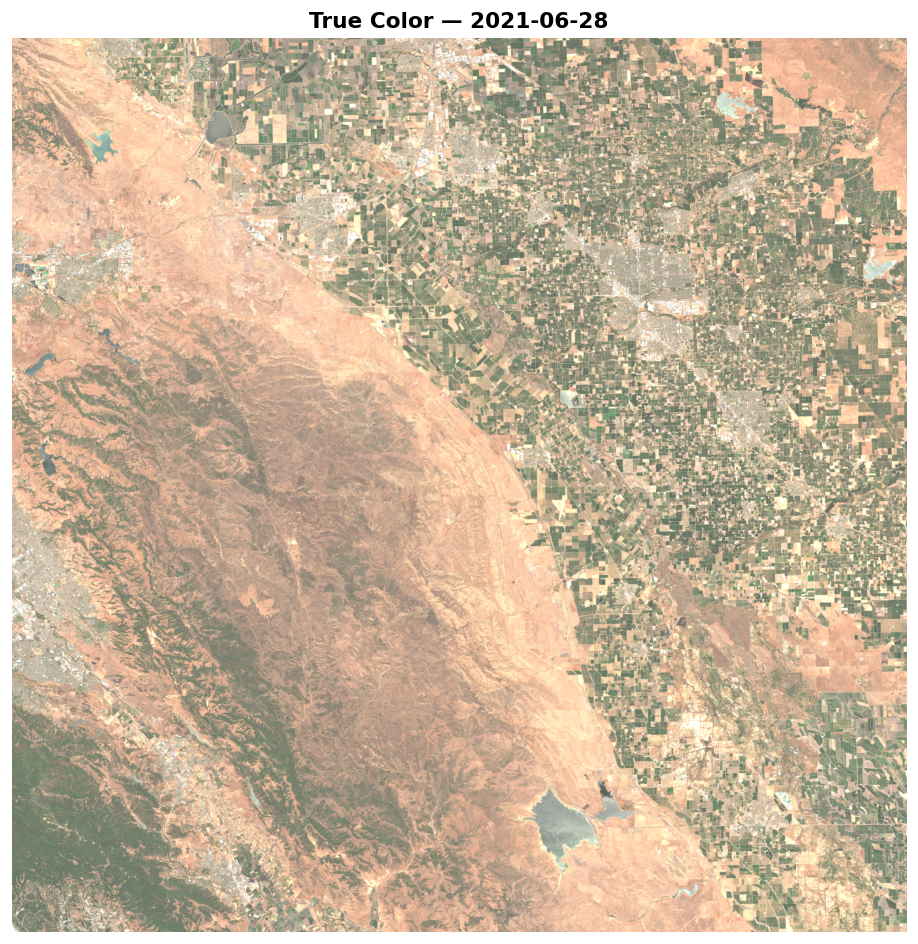

In [18]:
def plot_rgb(band_data, date, save_path=None):
    r = np.clip(band_data["B04"] / 3000., 0, 1)
    g = np.clip(band_data["B03"] / 3000., 0, 1)
    b = np.clip(band_data["B02"] / 3000., 0, 1)
    rgb = np.dstack([r, g, b])
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb)
    ax.set_title(f"True Color — {date}", fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150); print(f"Saved: {save_path}")
    plt.show()

if ts_data:
    plot_rgb(ts_data[0], dates[0],
             save_path=os.path.join(Config.OUTPUT_DIR, "rgb_composite.png"))

### 5.2 NDVI Time-Series for Sample Pixels

In [19]:
def plot_ndvi_timeseries(ts_indices, dates, n_samples=5, save_path=None):
    if not ts_indices or "NDVI" not in ts_indices[0]:
        print("NDVI not available"); return
    ndvi_stack = np.stack([s["NDVI"] for s in ts_indices])  # (T,H,W)
    H, W = ndvi_stack.shape[1:]
    np.random.seed(42)
    rows = np.random.randint(0, H, n_samples)
    cols = np.random.randint(0, W, n_samples)
    colors = plt.cm.Set1(np.linspace(0, 1, n_samples))

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (r, c) in enumerate(zip(rows, cols)):
        ax.plot(dates, ndvi_stack[:, r, c], "o-",
                color=colors[i], label=f"Pixel ({r},{c})", lw=2, ms=5)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set(xlabel="Date", ylabel="NDVI",
           title="NDVI Time-Series — Sample Pixels")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()

plot_ndvi_timeseries(ts_indices, dates,
    save_path=os.path.join(Config.OUTPUT_DIR, "ndvi_timeseries.png"))

NDVI not available


### 5.3 Mean NIR (B08) Heatmap

In [20]:
def plot_band_heatmap(ts_data, band="B08", save_path=None):
    stack = np.stack([s[band]/10000. for s in ts_data if band in s])
    mean_img = stack.mean(axis=0)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mean_img, cmap="YlGn")
    plt.colorbar(im, ax=ax, label=f"Mean {band} Reflectance")
    ax.set_title(f"Mean {band} (NIR) — All Scenes", fontweight="bold")
    ax.axis("off"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()

if ts_data:
    plot_band_heatmap(ts_data, band="B08",
        save_path=os.path.join(Config.OUTPUT_DIR, "nir_heatmap.png"))

ValueError: need at least one array to stack

### 5.4 Band Correlation Matrix (Single Scene)

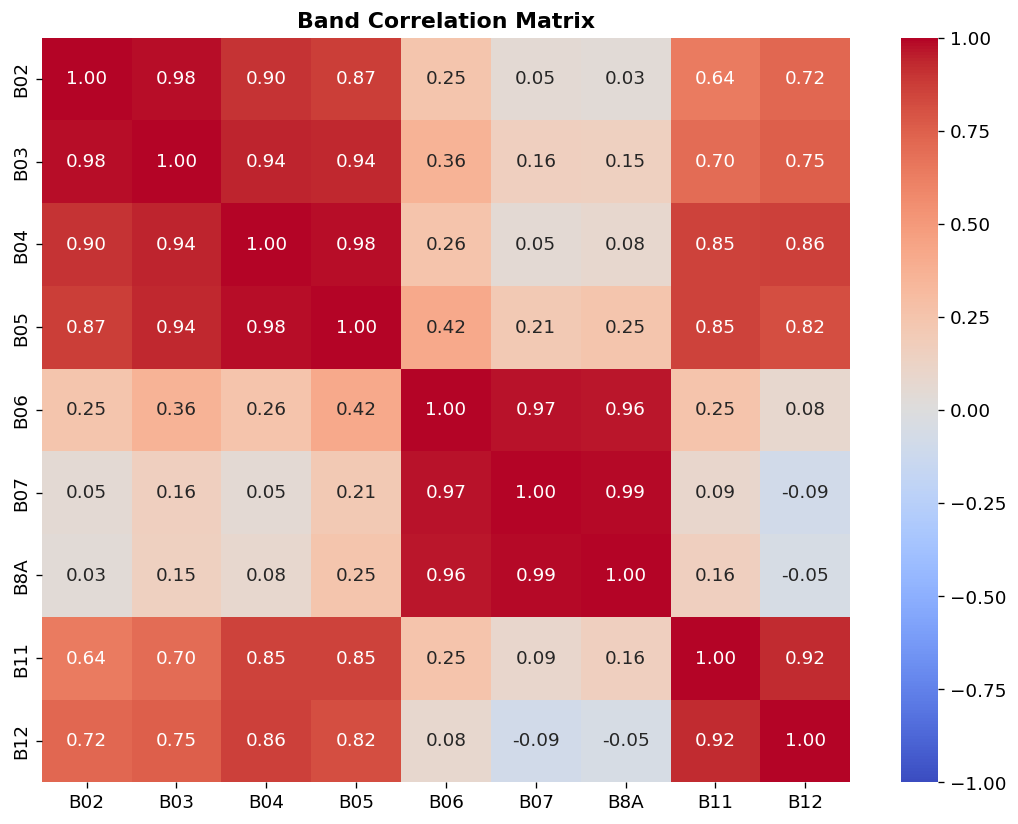

In [21]:
if ts_data:
    scene = ts_data[0]
    available_bands = [b for b in Config.BANDS if b in scene]
    mat = np.stack([scene[b].flatten() for b in available_bands], axis=1)

    # subsample for speed
    idx = np.random.choice(mat.shape[0], min(5000, mat.shape[0]), replace=False)
    corr = np.corrcoef(mat[idx].T)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                xticklabels=available_bands, yticklabels=available_bands,
                ax=ax, vmin=-1, vmax=1)
    ax.set_title("Band Correlation Matrix", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "band_correlation.png"), dpi=150)
    plt.show()

## 6. Load CDL Labels & Class Distribution

In [22]:
# ── Load CDL ──────────────────────────────────────────────────────────────
if os.path.exists(Config.CDL_PATH):
    with rasterio.open(Config.CDL_PATH) as src:
        cdl_array = src.read(1)
    print(f"CDL shape : {cdl_array.shape}")
    print(f"CDL dtype : {cdl_array.dtype}")
    print(f"Unique codes (sample): {np.unique(cdl_array)[:20]}")
else:
    print(f"⚠️  CDL not found at {Config.CDL_PATH}")
    print("Download from: https://nassgeodata.gmu.edu/CropScape")
    cdl_array = None

⚠️  CDL not found at C:\SII\aarn\projet\cdl\cdl_california_2021.tif
Download from: https://nassgeodata.gmu.edu/CropScape


In [23]:
def plot_class_distribution(cdl_array, cdl_classes, save_path=None):
    counts = {name: int((cdl_array == code).sum())
              for code, name in cdl_classes.items()
              if (cdl_array == code).sum() > 0}
    if not counts:
        print("No matching CDL classes found"); return

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
    bars = ax.bar(list(counts.keys()), list(counts.values()), color=colors,
                  edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%d", fontsize=8, padding=3)
    ax.set(xlabel="Crop Type", ylabel="Pixel Count",
           title="Class Distribution (CDL Ground Truth)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()

if cdl_array is not None:
    plot_class_distribution(cdl_array, Config.CDL_CLASSES,
        save_path=os.path.join(Config.OUTPUT_DIR, "class_distribution.png"))

### 6.1 Temporal NDVI Profiles by Crop Class

In [24]:
def plot_temporal_patterns_by_class(ts_indices, dates, cdl_array,
                                    cdl_classes, index="NDVI", save_path=None):
    stack = np.stack([s[index] for s in ts_indices if index in s])  # (T,H,W)
    T, H, W = stack.shape
    cdl_crop = cdl_array[:H, :W]
    fig, ax = plt.subplots(figsize=(13, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(cdl_classes)))
    for (code, name), color in zip(cdl_classes.items(), colors):
        mask = cdl_crop == code
        if mask.sum() < 10: continue
        mean_ts = stack[:, mask].mean(axis=1)
        ax.plot(dates, mean_ts, "o-", label=name, color=color, lw=2, ms=5)
    ax.set(xlabel="Date", ylabel=index,
           title=f"Mean {index} Temporal Profile by Crop Class")
    ax.legend(bbox_to_anchor=(1.01,1), fontsize=9)
    ax.grid(alpha=0.3); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()

if cdl_array is not None and ts_indices:
    plot_temporal_patterns_by_class(ts_indices, dates, cdl_array,
        Config.CDL_CLASSES, index="NDVI",
        save_path=os.path.join(Config.OUTPUT_DIR, "temporal_patterns.png"))

## 7. Temporal Interpolation
The paper resamples irregular acquisitions to **30 evenly-spaced timesteps** across the year.

In [ ]:
def temporal_interpolate(ts_list, dates, n_steps=30, year=2021):
    """Interpolate all channels to a fixed temporal grid. Returns (T, H, W, C)."""
    if not ts_list:
        raise ValueError("No scenes to interpolate")
    start    = np.datetime64(f"{year}-01-01")
    end      = np.datetime64(f"{year}-12-31")
    tgt_days = np.linspace(0, (end-start).astype(int), n_steps, dtype=int)
    src_days = ((dates - start).astype(int))

    channels = [k for k in ts_list[0] if k != "date"]
    H, W     = ts_list[0][channels[0]].shape
    result   = np.zeros((n_steps, H, W, len(channels)), dtype=np.float32)

    print(f"Interpolating {len(channels)} channels to {n_steps} timesteps ...")
    for ci, ch in enumerate(channels):
        stack = np.stack([s[ch] for s in ts_list])  # (T, H, W)
        # vectorised interpolation (pixel × timestep)
        flat = stack.reshape(len(ts_list), -1)       # (T, N)
        f    = interp1d(src_days, flat, axis=0, kind="linear",
                        bounds_error=False,
                        fill_value=(flat[0], flat[-1]))
        result[:, :, :, ci] = f(tgt_days).reshape(n_steps, H, W)
        if (ci + 1) % 5 == 0:
            print(f"  {ci+1}/{len(channels)} channels done")

    print(f"✅ Interpolated shape: {result.shape}  (T, H, W, C)")
    return result, channels


if ts_data:
    interpolated, channels = temporal_interpolate(
        ts_data, dates, n_steps=Config.N_TIMESTEPS, year=Config.YEAR)

Interpolating 9 channels to 30 timesteps ...


## 8. Normalization (Per-Channel Z-Score)

In [ ]:
def normalize(data):
    """Per-channel z-score: data shape (T, H, W, C)."""
    T, H, W, C = data.shape
    flat = data.reshape(-1, C)
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    normed = (data - mean) / std
    print(f"Normalization — mean range: [{mean.min():.1f}, {mean.max():.1f}]")
    print(f"              — std  range: [{std.min():.4f}, {std.max():.4f}]")
    return normed, mean, std

if ts_data:
    normalized, feat_mean, feat_std = normalize(interpolated)

## 9. Pixel Dataset Preparation

In [ ]:
def prepare_pixel_dataset(interpolated, cdl_array, cdl_classes):
    """Flatten (T,H,W,C) → (N,T,C) keeping only labelled pixels."""
    T, H, W, C = interpolated.shape
    cdl_crop    = cdl_array[:H, :W]
    valid_codes = list(cdl_classes.keys())
    mask        = np.isin(cdl_crop, valid_codes)

    X     = interpolated[:, mask, :].transpose(1, 0, 2)   # (N, T, C)
    y_raw = cdl_crop[mask]
    y     = np.array([valid_codes.index(v) for v in y_raw])

    print(f"✅ Dataset: {X.shape[0]:,} pixels | {T} timesteps | {C} channels")
    print(f"   Classes: {[cdl_classes[c] for c in valid_codes]}")
    return X, y


def train_val_test_split(X, y, tr=0.7, va=0.15, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(len(y))
    t1, t2 = int(len(y)*tr), int(len(y)*(tr+va))
    return (X[idx[:t1]], y[idx[:t1]],
            X[idx[t1:t2]], y[idx[t1:t2]],
            X[idx[t2:]], y[idx[t2:]])


if cdl_array is not None and ts_data:
    X, y = prepare_pixel_dataset(normalized, cdl_array, Config.CDL_CLASSES)
    class_names = list(Config.CDL_CLASSES.values())
    X_tr,y_tr,X_va,y_va,X_te,y_te = train_val_test_split(
        X, y, Config.TRAIN_RATIO, Config.VAL_RATIO)
    print(f"   Train: {len(y_tr):,} | Val: {len(y_va):,} | Test: {len(y_te):,}")

## 10. CNN-Transformer Model

Architecture as proposed in the paper:
```
Input (B, T, C)
   → Linear Projection → (B, T, D)
   → 1-D Temporal CNN  → (B, T, D)
   → + Positional Encoding
   → Transformer Encoder (N layers)
   → Global Average Pooling
   → Classification Head
   → (B, n_classes)
```

In [ ]:
try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✅ PyTorch {torch.__version__} | device: {device}")
except ImportError:
    TORCH_OK = False
    print("❌ PyTorch not found — run: pip install torch")

In [ ]:
if TORCH_OK:

    class TemporalCNN(nn.Module):
        """Local temporal feature extractor via 1-D convolutions."""
        def __init__(self, d, k=3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(d, d, k, padding=k//2),
                nn.BatchNorm1d(d), nn.GELU(),
                nn.Conv1d(d, d, k, padding=k//2),
                nn.BatchNorm1d(d), nn.GELU(),
            )
        def forward(self, x):          # x: (B, D, T)
            return self.net(x)


    class LightweightCNNTransformer(nn.Module):
        """
        Lightweight CNN-Transformer for pixel-based crop mapping.
        Wang et al. (2023).
        """
        def __init__(self, n_ch, n_t, n_cls,
                     d=64, n_heads=4, n_layers=2, dropout=0.1):
            super().__init__()
            self.proj   = nn.Linear(n_ch, d)
            self.cnn    = TemporalCNN(d)
            self.pos    = nn.Parameter(torch.zeros(1, n_t, d))
            nn.init.trunc_normal_(self.pos, std=0.02)
            enc = nn.TransformerEncoderLayer(
                d_model=d, nhead=n_heads,
                dim_feedforward=d*4, dropout=dropout,
                batch_first=True, activation="gelu")
            self.transformer = nn.TransformerEncoder(enc, n_layers)
            self.head = nn.Sequential(
                nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, n_cls))

        def forward(self, x):           # x: (B, T, C)
            x = self.proj(x)                              # (B,T,D)
            x = self.cnn(x.permute(0,2,1)).permute(0,2,1)# temporal CNN
            x = x + self.pos                              # positional enc
            x = self.transformer(x)                       # (B,T,D)
            x = x.mean(1)                                 # global avg pool
            return self.head(x)                           # (B,n_cls)


    # ── Instantiate ────────────────────────────────────────────────────────
    if cdl_array is not None and ts_data:
        model = LightweightCNNTransformer(
            n_ch=X.shape[2], n_t=Config.N_TIMESTEPS,
            n_cls=len(class_names), d=Config.HIDDEN_DIM,
            n_heads=Config.N_HEADS, n_layers=Config.N_LAYERS,
            dropout=Config.DROPOUT).to(device)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"Model parameters : {n_params:,}")
        print(model)

## 11. Training

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:

    def make_loader(X_arr, y_arr, shuffle=False):
        ds = TensorDataset(torch.tensor(X_arr, dtype=torch.float32),
                           torch.tensor(y_arr,  dtype=torch.long))
        return DataLoader(ds, batch_size=Config.BATCH_SIZE, shuffle=shuffle)

    train_loader = make_loader(X_tr, y_tr, shuffle=True)
    val_loader   = make_loader(X_va, y_va)
    test_loader  = make_loader(X_te, y_te)

    optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    print(f"Training for {Config.EPOCHS} epochs on {device} ...")
    for epoch in range(1, Config.EPOCHS + 1):
        # ── train ──────────────────────────────────────────────────────────
        model.train()
        t_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            t_losses.append(loss.item())

        # ── validate ────────────────────────────────────────────────────────
        model.eval()
        v_losses, preds, trues = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                v_losses.append(criterion(out, yb).item())
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(yb.cpu().numpy())

        scheduler.step()
        tl = np.mean(t_losses); vl = np.mean(v_losses)
        vf = f1_score(trues, preds, average="macro", zero_division=0)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_f1"].append(vf)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{Config.EPOCHS} | "                  f"train_loss={tl:.4f}  val_loss={vl:.4f}  val_F1={vf:.4f}")

    # ── Save ────────────────────────────────────────────────────────────────
    ckpt = os.path.join(Config.OUTPUT_DIR, "model_best.pt")
    torch.save(model.state_dict(), ckpt)
    print(f"\n✅ Model saved → {ckpt}")

### 11.1 Learning Curves

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history["train_loss"], label="Train", color="#E63946", lw=2)
    ax1.plot(history["val_loss"],   label="Val",   color="#457B9D", lw=2)
    ax1.set(title="Loss Curves", xlabel="Epoch", ylabel="Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history["val_f1"], color="#2A9D8F", lw=2)
    ax2.set(title="Validation Macro F1", xlabel="Epoch", ylabel="F1")
    ax2.grid(alpha=0.3)

    plt.suptitle("Training History", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), dpi=150)
    plt.show()

## 12. Evaluation on Test Set

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            all_true.extend(yb.numpy())

    oa  = accuracy_score(all_true, all_preds)
    mf1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

    print("=" * 55)
    print(f"  Overall Accuracy (OA) : {oa:.4f}")
    print(f"  Macro F1-Score        : {mf1:.4f}")
    print("=" * 55)
    print(classification_report(all_true, all_preds,
                                target_names=class_names, zero_division=0))

### 12.1 Confusion Matrix

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:
    cm = confusion_matrix(all_true, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set(xlabel="Predicted", ylabel="True",
           title="Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()

### 12.2 Per-Class F1 Bar Chart

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:
    per_class_f1 = f1_score(all_true, all_preds, average=None, zero_division=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(class_names[:len(per_class_f1)], per_class_f1,
                  color=plt.cm.viridis(np.linspace(0.2, 0.8, len(per_class_f1))),
                  edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", fontsize=9)
    ax.set(ylim=(0, 1.1), xlabel="Crop Class", ylabel="F1 Score",
           title="Per-Class F1 Score")
    ax.axhline(mf1, color="red", ls="--", lw=1.5, label=f"Macro F1={mf1:.3f}")
    ax.legend(); plt.xticks(rotation=30, ha="right"); plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "per_class_f1.png"), dpi=150)
    plt.show()

## 13. Results Summary

In [ ]:
if TORCH_OK and cdl_array is not None and ts_data:
    print("\n" + "="*60)
    print("  RESULTS SUMMARY — Part 1 Base Model")
    print("="*60)
    print(f"  Scenes used       : {len(ts_data)}")
    print(f"  Timesteps         : {Config.N_TIMESTEPS}")
    print(f"  Channels          : {X.shape[2]}")
    print(f"  Training samples  : {len(y_tr):,}")
    print(f"  Test samples      : {len(y_te):,}")
    print(f"  Model parameters  : {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Overall Accuracy  : {oa:.4f}")
    print(f"  Macro F1-Score    : {mf1:.4f}")
    print(f"  Outputs saved to  : {Config.OUTPUT_DIR}")
    print("="*60)
else:
    print("⚠️  Run all cells above with valid SAFE_DIR and CDL_PATH to see results")